In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
pd.set_option('display.max_columns', None)

In [3]:
chur = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
chur.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print(chur.shape, chur.dtypes, chur.isnull().sum(), chur.describe(), chur.nunique(), sep = '\n')

(7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod

In [6]:
chur['TotalCharges'] = pd.to_numeric(chur['TotalCharges'], errors='coerce')

In [7]:
print(chur['TotalCharges'].isnull().sum()) 

11


In [8]:
print(chur['Churn'].value_counts(normalize=True) * 100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


#Class Imbalance Detected

Text(0.5, 1.0, 'Tenure by Churn')

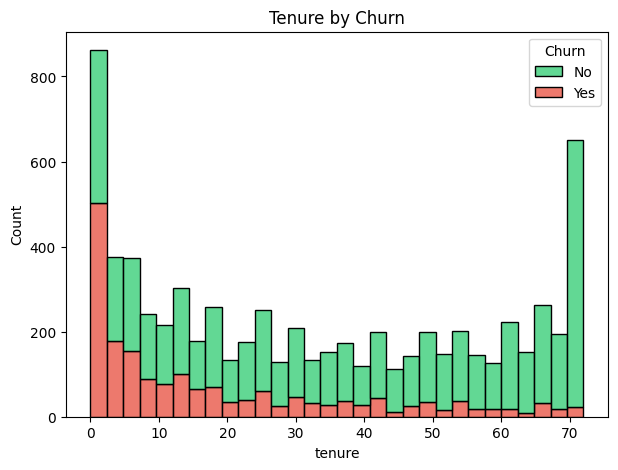

In [9]:
plt.figure(figsize=(7,5))
sns.histplot(data=chur, x='tenure', hue='Churn', bins=30, multiple='stack', palette=['#2ecc71','#e74c3c'])
plt.title('Tenure by Churn')

Text(0.5, 1.0, 'Monthly Charges by Churn')

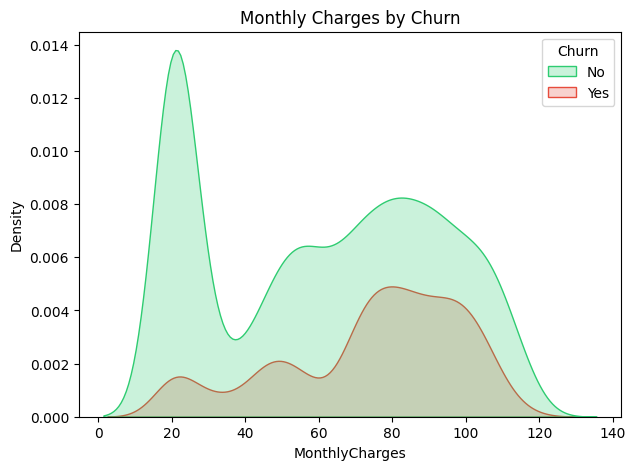

In [10]:
plt.figure(figsize=(7,5))
sns.kdeplot(data=chur, x='MonthlyCharges', hue='Churn', fill=True, palette=['#2ecc71','#e74c3c'])
plt.title('Monthly Charges by Churn')

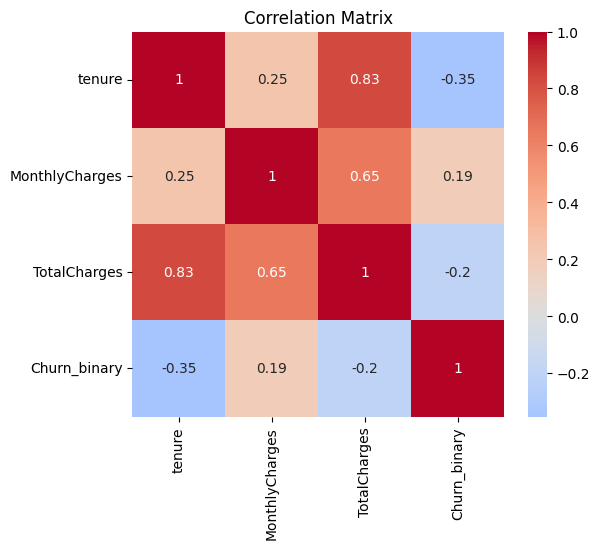

In [11]:
df_temp = chur.copy()
df_temp['Churn_binary'] = df_temp['Churn'].map({'Yes': 1, 'No': 0})

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_binary']
plt.figure(figsize=(6,5))
sns.heatmap(df_temp[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [25]:
ch = chur.copy()

ch.drop(['customerID'], axis=1, inplace=True)

In [26]:
ch['TotalCharges'] = pd.to_numeric(ch['TotalCharges'], errors='coerce')
ch['TotalCharges']= ch['TotalCharges'].fillna(0)
ch['Churn'] = ch['Churn'].map({'Yes': 1, 'No': 0})


In [27]:
for col in ch.columns:
    print(f"Unique values in {col}: {ch[col].unique()}")

Unique values in gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Unique values in SeniorCitizen: [0 1]
Unique values in Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Unique values in Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Unique values in tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
Unique values in PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Unique values in MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
Unique values in InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
Unique values in OnlineSecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Unique values in OnlineBackup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 

In [28]:
cols_no_internet = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                          'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_no_internet:
    ch[col] = ch[col].replace('No internet service', 'No')

ch['MultipleLines'] = ch['MultipleLines'].replace('No phone service', 'No')

In [29]:
binary_cols = []
multi_cols = []

for col in ch.select_dtypes(include='str').columns:
    if ch[col].nunique() == 2:
        binary_cols.append(col)
    else:
        multi_cols.append(col)

print("Binary columns:", binary_cols)
print("Multi-category columns:", multi_cols)

Binary columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']
Multi-category columns: ['InternetService', 'Contract', 'PaymentMethod']


In [30]:
le = LabelEncoder()
for col in binary_cols:
    ch[col] = le.fit_transform(ch[col])

ch = pd.get_dummies(ch, columns=multi_cols, drop_first=True)
#changing boolean columns to int
bool_cols = ch.select_dtypes(include='bool').columns
for col in bool_cols:
    ch[col] = ch[col].astype(int)

In [31]:

print(ch.shape)
ch.head()

(7043, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1,1,0,0,0,0,1,0


In [32]:
y = ch['Churn']
X = ch.drop('Churn', axis=1)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
num_f = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
X_train_sc= X_train.copy()
X_test_sc= X_test.copy()
X_train_sc[num_f] = scaler.fit_transform(X_train[num_f])
X_test_sc[num_f] = scaler.transform(X_test[num_f])

In [38]:
log = LogisticRegression(max_iter=1000, random_state=42)
log.fit(X_train_sc, y_train)

y_pred_lr= log.predict(X_test_sc)
y_proba_lr= log.predict_proba(X_test_sc)[:, 1]

print("Logistic Regression: ")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, y_proba_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression: 
Accuracy: 0.8055358410220014
F1 Score: 0.6028985507246377
AUC: 0.8422330724121005
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [40]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train) 

y_pred_rf= rf.predict(X_test)
y_proba_rf= rf.predict_proba(X_test)[:, 1]

print("Random Forest: ")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest: 
Accuracy: 0.7892122072391767
F1 Score: 0.5573770491803278
AUC: 0.827936655558139
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



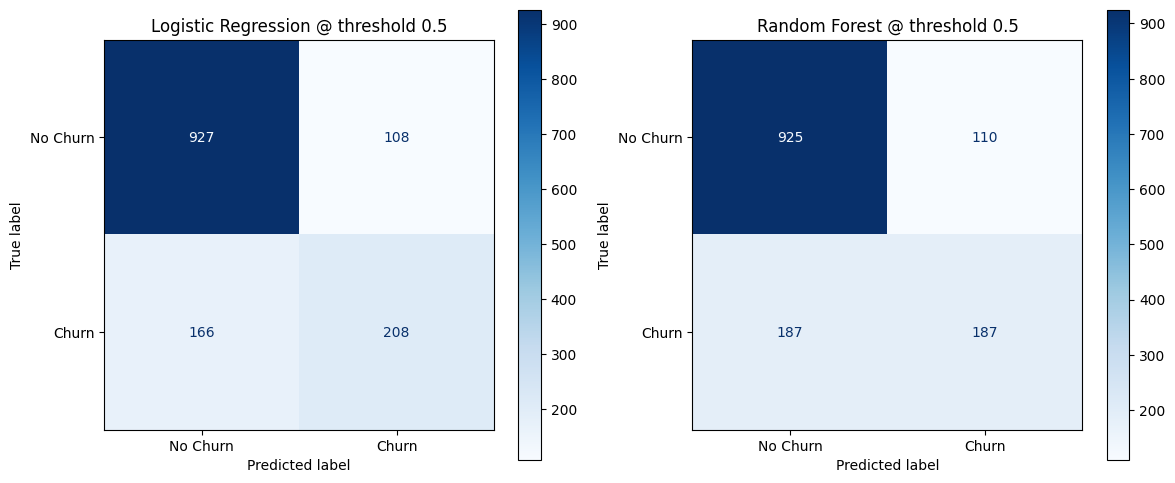

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['No Churn', 'Churn']

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=labels, cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression @ threshold 0.5')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=labels, cmap='Blues', ax=axes[1])
axes[1].set_title('Random Forest @ threshold 0.5')

plt.tight_layout()
plt.show()

In [44]:
baseline_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'F1': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
    'AUC': [roc_auc_score(y_test, y_proba_lr), roc_auc_score(y_test, y_proba_rf)],
})

baseline_results.to_csv('baseline_results.csv', index=False)
print(baseline_results)

                 Model  Accuracy        F1       AUC
0  Logistic Regression  0.805536  0.602899  0.842233
1        Random Forest  0.789212  0.557377  0.827937
